In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from src.config import FIG_DIR, PROCESSED_DIR
from src.evaluate import results_table, score, temporal_split
from src.features import TARGET

df = pd.read_parquet(PROCESSED_DIR / "features.parquet")
train, val, test = temporal_split(df)

rows = [
    score("Naive-24 (same hour yesterday)", val[TARGET], val["lag_24"]),
    score("Naive-168 (same hour last week)", val[TARGET], val["lag_168"]),
]
table = results_table(rows)
print(table.to_string(index=False))

 train:  48,599 rows   2019-01-15 -> 2024-07-31
   val:   8,760 rows   2024-07-31 -> 2025-07-31
  test:   8,733 rows   2025-07-31 -> 2026-07-31
                          model   MAE_MW  RMSE_MW  MAPE_pct
 Naive-24 (same hour yesterday)  975.286 1399.683     5.540
Naive-168 (same hour last week) 1500.454 2202.822     8.306


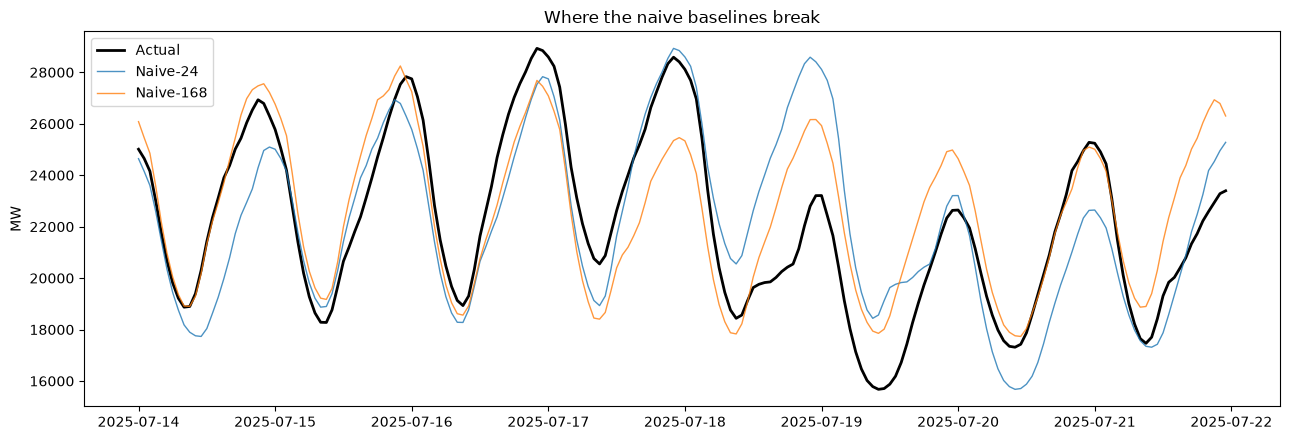

In [2]:
week = val.loc["2025-07-14":"2025-07-21"]   # adjust to a week inside your val range

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(week.index, week[TARGET], label="Actual", linewidth=2, color="black")
ax.plot(week.index, week["lag_24"], label="Naive-24", linewidth=1, alpha=0.8)
ax.plot(week.index, week["lag_168"], label="Naive-168", linewidth=1, alpha=0.8)
ax.set_title("Where the naive baselines break")
ax.set_ylabel("MW")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "06_baseline_week.png", dpi=130)
plt.show()